# **Kết quả thực nghiệm với ma trận ngẫu nhiên kích thước n = [50, 100, 200, 500, 1000]**

========== BENCHMARK RANDOM ==========
Ma tran su dung trong benchmark nay la ma tran ngau nhien thuong (khong rang buoc SPD).
Sai so tuong doi: ||A x_hat - b||_2 / ||b||_2

[========== n = 50 ==========]
 - Khử Gauss                :   0.0032s | Sai so: 3.29e-16 | Thanh cong: 5/5
 - Phân rã Cholesky         : THAT BAI (0/5). Vi du loi: Matrix must be symmetric.
 - Hệ PT Chuẩn (Cholesky)   :   0.0090s | Sai so: 2.82e-16 | Thanh cong: 5/5
 - Lặp Gauss-Seidel         :   0.0007s | Sai so: 1.95e-09 | Thanh cong: 5/5

[========== n = 100 ==========]
 - Khử Gauss                :   0.0202s | Sai so: 4.83e-16 | Thanh cong: 5/5
 - Phân rã Cholesky         : THAT BAI (0/5). Vi du loi: Matrix must be symmetric.
 - Hệ PT Chuẩn (Cholesky)   :   0.0732s | Sai so: 4.03e-16 | Thanh cong: 5/5
 - Lặp Gauss-Seidel         :   0.0027s | Sai so: 1.52e-09 | Thanh cong: 5/5

[========== n = 200 ==========]
 - Khử Gauss                :   0.1777s | Sai so: 7.18e-16 | Thanh cong: 5/5
 - Phân rã Cholesky         : THAT BAI (0/5). Vi du loi: Matrix must be symmetric.
 - Hệ PT Chuẩn (Cholesky)   :   0.5643s | Sai so: 4.79e-16 | Thanh cong: 5/5
 - Lặp Gauss-Seidel         :   0.0092s | Sai so: 3.82e-09 | Thanh cong: 5/5

[========== n = 500 ==========]
 - Khử Gauss                :   2.9023s | Sai so: 1.14e-15 | Thanh cong: 5/5
 - Phân rã Cholesky         : THAT BAI (0/5). Vi du loi: Matrix must be symmetric.
 - Hệ PT Chuẩn (Cholesky)   :   9.1724s | Sai so: 6.91e-16 | Thanh cong: 5/5
 - Lặp Gauss-Seidel         :   0.0608s | Sai so: 1.07e-08 | Thanh cong: 5/5

[========== n = 1000 ==========]
 - Khử Gauss                :  23.4276s | Sai so: 1.61e-15 | Thanh cong: 5/5
 - Phân rã Cholesky         : THAT BAI (0/5). Vi du loi: Matrix must be symmetric.
 - Hệ PT Chuẩn (Cholesky)   :  82.0891s | Sai so: 9.79e-16 | Thanh cong: 5/5
 - Lặp Gauss-Seidel         :   0.2480s | Sai so: 2.62e-09 | Thanh cong: 5/5

# **Nhận xét:**

## **1. Hiệu năng**

- Thời gian của Khử Gauss tăng mạnh theo kích thước bài toán: từ 0.0032s (n=50) lên 23.4276s (n=1000), phù hợp xu hướng tăng nhanh của nhóm thuật toán khử trực tiếp.

- Hệ PT Chuẩn (Cholesky) là phương pháp chậm nhất ở n lớn: 82.0891s tại n=1000, chậm hơn rõ rệt so với Khử Gauss do phải tạo và giải hệ trên ma trận biến đổi. 

- Lặp Gauss-Seidel có thời gian nhanh nhất trong các phương pháp thành công ở mọi n (0.2480s tại n=1000), cho thấy lợi thế về tốc độ trong bộ dữ liệu hiện tại.

- Phân rã Cholesky thất bại 100% trên bộ ma trận ngẫu nhiên này (0/5 ở mọi n) với lỗi matrix must be symmetric, phù hợp điều kiện áp dụng của Cholesky.

## **2. Độ chính xác**

- Khử Gauss và Hệ PT Chuẩn cho sai số rất nhỏ, cỡ 10^-16 đến 10^-15.

- Gauss-Seidel có sai số lớn hơn, cỡ 10^-9 đến 10^-8, vẫn chấp nhận được cho nhiều bài toán thực hành nhưng kém chính xác hơn các phương pháp trực tiếp.


# **Biểu đồ so sánh thời gian chạy (log-log)**

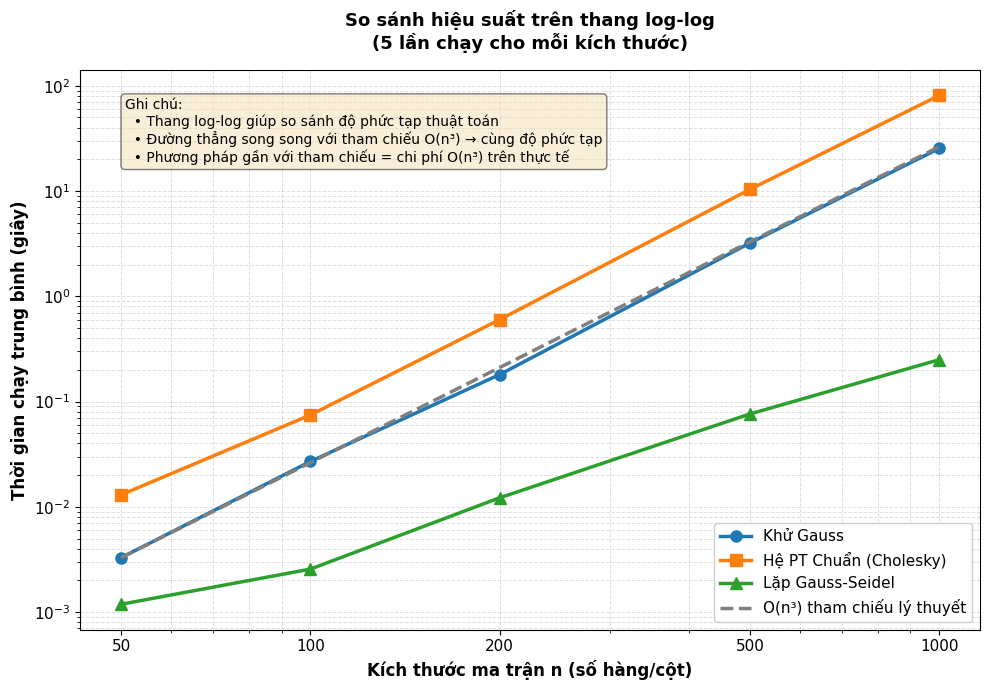

In [3]:
from benchmark import run_benchmark
import matplotlib.pyplot as plt

# Lấy số liệu trực tiếp từ hàm benchmark, không dùng numpy và không nhập tay mảng số
results = run_benchmark(verbose=False)

# Trích xuất các giá trị n và thời gian chạy cho từng phương pháp
n_values = sorted(results['Khử Gauss'].keys())
gauss_times = [results['Khử Gauss'][n]['avg_time'] for n in n_values]
cholesky_eq_times = [results['Hệ PT Chuẩn (Cholesky)'][n]['avg_time'] for n in n_values]
gauss_seidel_times = [results['Lặp Gauss-Seidel'][n]['avg_time'] for n in n_values]

# Đường tham chiếu O(n^3): chuẩn hóa theo điểm đầu của Khử Gauss
# Công thức: T(n) = T(n₀) × (n/n₀)³, với n₀ = 50
ref_on3 = [gauss_times[0] * (n / n_values[0]) ** 3 for n in n_values]

# ===== Vẽ biểu đồ log-log =====
plt.figure(figsize=(10, 7))

# Plot các đường cho từng phương pháp
plt.loglog(n_values, gauss_times, marker='o', markersize=8, linewidth=2.5, label='Khử Gauss')
plt.loglog(n_values, cholesky_eq_times, marker='s', markersize=8, linewidth=2.5, label='Hệ PT Chuẩn (Cholesky)')
plt.loglog(n_values, gauss_seidel_times, marker='^', markersize=8, linewidth=2.5, label='Lặp Gauss-Seidel')
plt.loglog(n_values, ref_on3, linestyle='--', linewidth=2.5, color='gray', label='O(n³) tham chiếu lý thuyết')

# Thiết lập tất cả các giá trị n trên trục x
plt.xticks(n_values, [str(n) for n in n_values], fontsize=11)
plt.yticks(fontsize=11)

# ===== Nhãn và tiêu đề =====
plt.xlabel('Kích thước ma trận n (số hàng/cột)', fontsize=12, fontweight='bold')
plt.ylabel('Thời gian chạy trung bình (giây)', fontsize=12, fontweight='bold')
plt.title('So sánh hiệu suất trên thang log-log\n(5 lần chạy cho mỗi kích thước)', 
          fontsize=13, fontweight='bold', pad=15)

# ===== Grid và legend =====
plt.grid(True, which='both', linestyle='--', alpha=0.4, linewidth=0.7)
plt.legend(fontsize=11, loc='best', framealpha=0.95)

# ===== Chú thích chi tiết =====
# Chú thích cho đường tham chiếu
plt.text(0.05, 0.95, 
         'Ghi chú:\n' +
         '  • Thang log-log giúp so sánh độ phức tạp thuật toán\n' +
         '  • Đường thẳng song song với tham chiếu O(n³) → cùng độ phức tạp\n' +
         '  • Phương pháp gần với tham chiếu = chi phí O(n³) trên thực tế',
         transform=plt.gca().transAxes,
         fontsize=10,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# **Kết quả phân tích ổn định 2 loại ma trận: SPD và Hilbert**

========== BENCHMARK TÍNH ỔN ĐỊNH SỐ ==========
Muc tieu: So sanh do chinh xac tren ma tran Tot (SPD) va ma tran Xau (Hilbert).
Kich thuoc thu nghiem: n = 10. So lan chay: 5
Sai so tuong doi: ||A x_hat - b||_2 / ||b||_2

[========== Ma tran: SPD (Well-conditioned) ==========]
 - Khử Gauss                :   0.0001s | Sai so: 9.45e-17 | Thanh cong: 5/5
 - Phân rã Cholesky         :   0.0001s | Sai so: 7.72e-17 | Thanh cong: 5/5
 - Hệ PT Chuẩn (Cholesky)   :   0.0001s | Sai so: 3.70e-16 | Thanh cong: 5/5
 - Lặp Gauss-Seidel         :   0.0002s | Sai so: 1.03e-09 | Thanh cong: 5/5

[========== Ma tran: Hilbert (Ill-conditioned) ==========]
 - Khử Gauss                : THAT BAI (0/5). Vi du loi: he khong co nghiem duy nhat
 - Phân rã Cholesky         :   0.0001s | Sai so: 8.50e-17 | Thanh cong: 5/5
 - Hệ PT Chuẩn (Cholesky)   : THAT BAI (0/5). Vi du loi: Matrix is not positive definite.
 - Lặp Gauss-Seidel         :   0.0025s | Sai so: 8.35e-06 | Thanh cong: 5/5

# **Nhận xét sâu về ổn định số: SPD vs Hilbert**

- Trên ma trận SPD, cả bốn phương pháp đều cho sai số rất nhỏ. Điều này phản ánh đúng tính chất **well-conditioned** của SPD: các phép biến đổi số học ít làm khuếch đại sai số đầu vào.

- Ở bộ benchmark ngẫu nhiên, Khử Gauss và Hệ PT Chuẩn đều ổn định về sai số ở mức $10^{-16}$ đến $10^{-15}$. Tuy nhiên, Gauss-Seidel có sai số cao hơn khoảng 3 đến 5 bậc độ lớn, tức vào khoảng $10^{-9}$ đến $10^{-8}$. Đây là dấu hiệu điển hình của phương pháp lặp: tốc độ tốt nhưng độ chính xác thấp hơn phương pháp trực tiếp.

- Trên ma trận Hilbert, khác biệt giữa các phương pháp thể hiện rất rõ. Khử Gauss thất bại vì hệ trở nên quá xấu điều kiện, còn Hệ PT Chuẩn cũng không còn phù hợp vì ma trận trung gian không còn đảm bảo dương xác định trong quá trình tính toán số. Ngược lại, Gauss-Seidel vẫn có thể chạy nhưng sai số tăng lên đáng kể, cho thấy việc hội tụ không đồng nghĩa với kết quả chính xác cao.

- Đáng chú ý là trong bộ test Hilbert kích thước nhỏ $n=10$, Cholesky vẫn cho sai số rất nhỏ và thành công. Tuy nhiên, đây không nên xem là kết luận tổng quát: Hilbert nổi tiếng là ma trận xấu điều kiện, nên khi kích thước tăng lên, sai số thường bị khuếch đại nhanh hơn. Vì vậy, kết quả này chỉ phản ánh một điểm dữ liệu cụ thể, không phủ nhận bản chất kém ổn định của Hilbert.

- Kết luận thực nghiệm: nếu mục tiêu là **độ chính xác**, các phương pháp trực tiếp trên SPD vẫn là lựa chọn tốt hơn. Nếu mục tiêu là **tốc độ** và chấp nhận sai số lớn hơn, Gauss-Seidel có lợi thế rõ ràng. Ngược lại, với bài toán xấu điều kiện như Hilbert, cần rất thận trọng khi chọn phương pháp vì sai số số học có thể làm kết quả mất tin cậy.

## **Kết luận sâu về ổn định số**

- Kết quả trên ma trận **SPD** cho thấy đây là nhóm dữ liệu "an toàn" cho cả phương pháp trực tiếp lẫn phương pháp lặp. Sai số của Khử Gauss và Cholesky đều ở mức khoảng $10^{-16}$ đến $10^{-17}$, tức gần với giới hạn chính xác của số thực dấu chấm động trong Python. Điều này xác nhận rằng với ma trận có điều kiện tốt, các phép biến đổi số học hầu như không khuếch đại sai số đầu vào.

- **Gauss-Seidel** có ưu thế về thời gian nhưng sai số lớn hơn rõ rệt: trên SPD, sai số của nó ở mức $10^{-9}$, tức kém hơn các phương pháp trực tiếp khoảng 7 bậc độ lớn. Đây là đánh đổi quan trọng: tốc độ tốt hơn, nhưng độ chính xác giảm đáng kể. Vì vậy, Gauss-Seidel phù hợp khi cần lời giải gần đúng nhanh, không phù hợp nếu bài toán yêu cầu độ chính xác cao.

- Trên ma trận **Hilbert**, bức tranh thay đổi rõ rệt. Khử Gauss thất bại vì hệ không còn nghiệm duy nhất theo tiêu chí số học, còn phương pháp Hệ PT Chuẩn cũng thất bại vì ma trận trung gian không đảm bảo dương xác định trong quá trình tính toán. Nói cách khác, với ma trận xấu điều kiện, chỉ cần sai số rất nhỏ trong dữ liệu hoặc trong bước khử cũng có thể làm kết quả mất tin cậy.

- Việc **Cholesky vẫn thành công ở n = 10** với sai số nhỏ là một trường hợp cục bộ, không nên hiểu là Hilbert "ổn định". Đây chỉ là một điểm kích thước nhỏ nơi hệ vẫn còn đủ tốt để thuật toán chạy được; khi kích thước tăng, Hilbert thường trở nên kém ổn định rất nhanh. Do đó, kết quả này là ngoại lệ có điều kiện, không phải quy luật chung.

- Nếu nhìn cả hai bộ benchmark cùng lúc, có thể kết luận rằng bài toán có **ba lớp đánh đổi**: 1) phương pháp trực tiếp cho độ chính xác cao hơn nhưng chậm hơn khi n lớn; 2) phương pháp lặp nhanh hơn nhưng sai số lớn hơn; 3) chất lượng ma trận đầu vào quyết định mạnh đến việc thuật toán có đáng tin cậy hay không.

- Về mặt thực nghiệm, phần benchmark đã chứng minh rằng chỉ nhìn vào thời gian chạy là chưa đủ. Cần đồng thời xét **thời gian, sai số, và tính hội tụ**, vì một phương pháp chạy nhanh nhưng sai số lớn hoặc thất bại trên dữ liệu xấu thì không thể xem là tốt hơn trong thực tế.

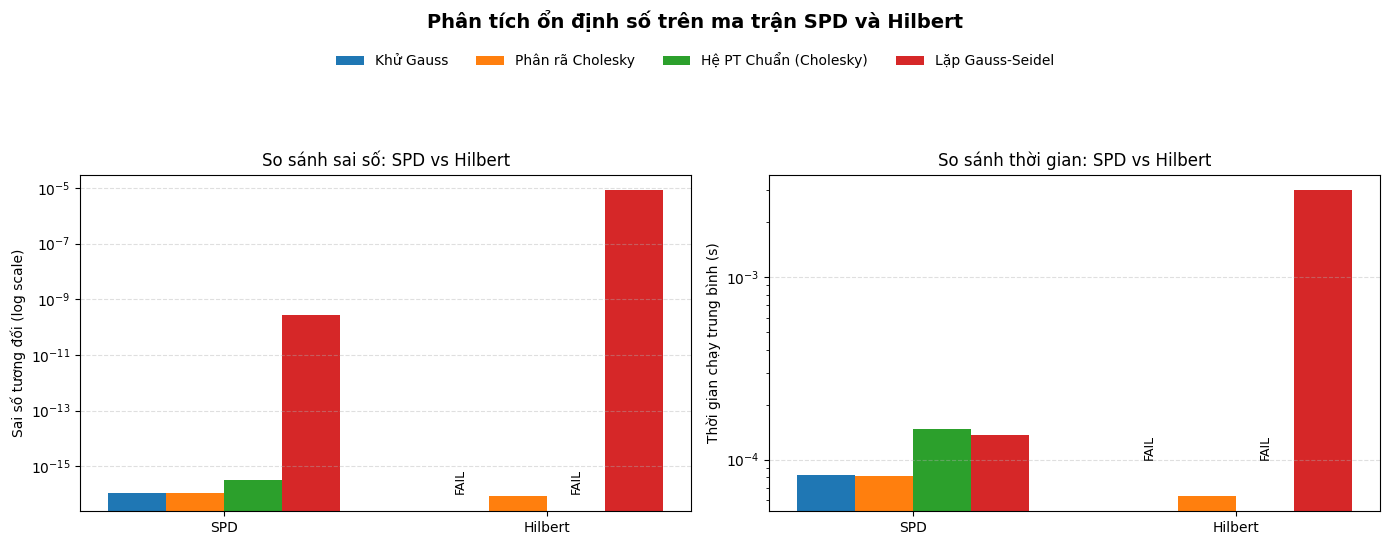

In [8]:
from benchmark import run_benchmark_stability
import matplotlib.pyplot as plt

stability_results = run_benchmark_stability(verbose=False)

matrix_types = ['SPD', 'Hilbert']
methods = ['Khử Gauss', 'Phân rã Cholesky', 'Hệ PT Chuẩn (Cholesky)', 'Lặp Gauss-Seidel']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Lấy sai số và thời gian để vẽ song song hai góc nhìn: tốc độ và độ chính xác
errors = {m: [] for m in methods}
times = {m: [] for m in methods}
for matrix_type in matrix_types:
    for method in methods:
        metric = stability_results[matrix_type][method]
        errors[method].append(metric['avg_error'] if metric['avg_error'] is not None else float('nan'))
        times[method].append(metric['avg_time'] if metric['avg_time'] is not None else float('nan'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bar_width = 0.18
positions = [0, 1]

# Biểu đồ 1: sai số tương đối
for idx, method in enumerate(methods):
    x_positions = [p + (idx - 1.5) * bar_width for p in positions]
    axes[0].bar(x_positions, errors[method], width=bar_width, label=method, color=colors[idx])
    for x_pos, value in zip(x_positions, errors[method]):
        if value != value:
            axes[0].text(x_pos, 1e-16, 'FAIL', ha='center', va='bottom', fontsize=9, rotation=90)
axes[0].set_xticks(positions)
axes[0].set_xticklabels(matrix_types)
axes[0].set_yscale('log')
axes[0].set_ylabel('Sai số tương đối (log scale)')
axes[0].set_title('So sánh sai số: SPD vs Hilbert')
axes[0].grid(True, axis='y', linestyle='--', alpha=0.4)

# Biểu đồ 2: thời gian chạy
for idx, method in enumerate(methods):
    x_positions = [p + (idx - 1.5) * bar_width for p in positions]
    axes[1].bar(x_positions, times[method], width=bar_width, label=method, color=colors[idx])
    for x_pos, value in zip(x_positions, times[method]):
        if value != value:
            axes[1].text(x_pos, 1e-4, 'FAIL', ha='center', va='bottom', fontsize=9, rotation=90)
axes[1].set_xticks(positions)
axes[1].set_xticklabels(matrix_types)
axes[1].set_yscale('log')
axes[1].set_ylabel('Thời gian chạy trung bình (s)')
axes[1].set_title('So sánh thời gian: SPD vs Hilbert')
axes[1].grid(True, axis='y', linestyle='--', alpha=0.4)

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle('Phân tích ổn định số trên ma trận SPD và Hilbert', fontsize=14, fontweight='bold', y=1.08)
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()